# <h1 style='background:#f0c2c1; border:2; border-radius: 10px; font-size:300%; font-weight: bold; color:black'><center>House Price Prediction</center></h1> 
 


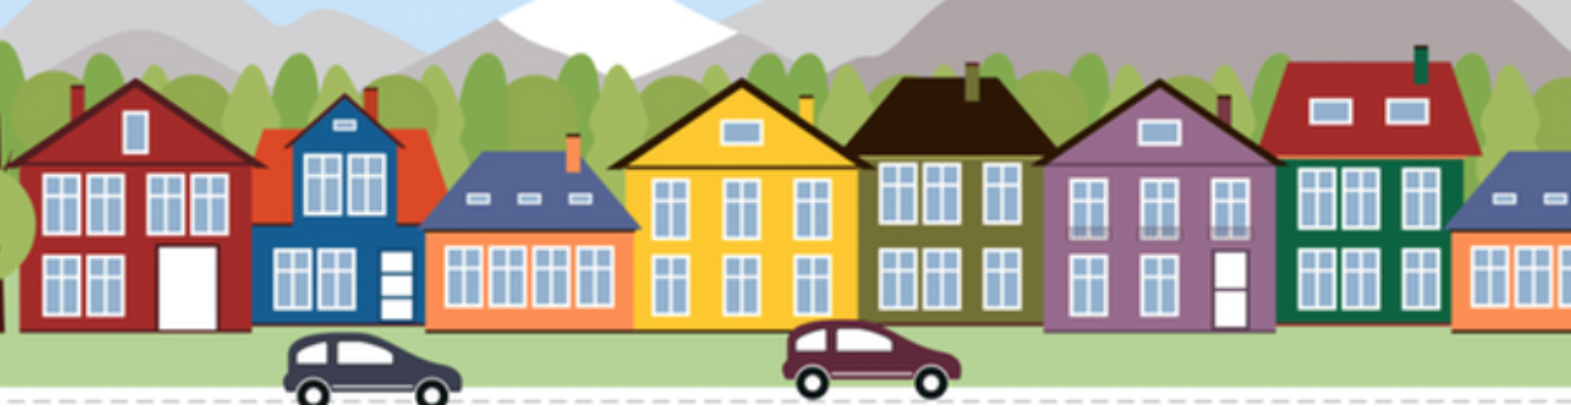


With the aim to ensure reproducibility between runs of the same notebook, for each step that includes some element of randomness, it is extremely important that we set the seed.

In [ ]:
!pip install feature-engine==1.0.2 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,Binarizer

from feature_engine.imputation import (
    AddMissingIndicator,
    MeanMedianImputer,
    CategoricalImputer,
)

from feature_engine.encoding import (
RareLabelEncoder,
    OrdinalEncoder,
)

from feature_engine.transformation import LogTransformer
from feature_engine.selection import DropFeatures
from feature_engine.wrappers import SklearnTransformerWrapper



# ⛰️ Customized Transformer variable

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin



class TemporalVariableTransformer(BaseEstimator, TransformerMixin):
	# Temporal elapsed time transformer

    def __init__(self, variables, reference_variable):
        
        if not isinstance(variables, list):
            raise ValueError('variables should be a list')
        
        self.variables = variables
        self.reference_variable = reference_variable

    def fit(self, X, y=None):
        # we need this step to fit the sklearn pipeline
        return self

    def transform(self, X):

    	# so that we do not over-write the original dataframe
        X = X.copy()
        
        for feature in self.variables:
            X[feature] = X[self.reference_variable] - X[feature]

        return X



# categorical missing value imputer
class Mapper(BaseEstimator, TransformerMixin):

    def __init__(self, variables, mappings):

        if not isinstance(variables, list):
            raise ValueError('variables should be a list')

        self.variables = variables
        self.mappings = mappings

    def fit(self, X, y=None):
        # we need the fit statement to accomodate the sklearn pipeline
        return self

    def transform(self, X):
        X = X.copy()
        for feature in self.variables:
            X[feature] = X[feature].map(self.mappings)

        return X

In [ ]:
train_data= pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

test_data = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

In [ ]:
train_data.shape

In [ ]:
train_data['MSSubClass'] = train_data['MSSubClass'].astype('O')

# 🚀 Separate dataset into train and valid
It is important to separate our data intro training and valid set.

When we engineer features, some techniques learn parameters from data. It is important to learn these parameters only from the train set. This is to avoid over-fitting.

Our feature engineering techniques will learn:

* mean
* mode
* exponents for the yeo-johnson
* category frequency
* and category to number mappings

from the train set.

**Separating the data into train and test involves randomness, therefore, we need to set the seed.**

In [ ]:
# Let's separate into train and test set
# Remember to set the seed (random_state for this sklearn function)

X_train,X_valid,y_train,y_valid = train_test_split(
    train_data.drop(['Id','SalePrice'],axis=1),
    train_data['SalePrice'],
    test_size=0.1,
    random_state=0,
)
X_train.shape,X_valid.shape

# 🏠 Target
We apply the logarithm

In [ ]:
y_train = np.log(y_train)
y_valid = np.log(y_valid)

## ✍🏼  Initialization 

In [ ]:
# categorical variables with NA in train set
CATEGORICAL_VARS_WITH_NA_FREQUENT = ['BsmtQual', 'BsmtExposure',
                                     'BsmtFinType1', 'GarageFinish']


CATEGORICAL_VARS_WITH_NA_MISSING = ['FireplaceQu']


# numerical variables with NA in train set
NUMERICAL_VARS_WITH_NA = ['LotFrontage']


TEMPORAL_VARS = ['YearRemodAdd']
REF_VAR = "YrSold"

# this variable is to calculate the temporal variable,
# can be dropped afterwards
DROP_FEATURES = ["YrSold"]

# variables to log transform
NUMERICALS_LOG_VARS = ["LotFrontage", "1stFlrSF", "GrLivArea"]


# variables to binarize
BINARIZE_VARS = ['ScreenPorch']

# variables to map
QUAL_VARS = ['ExterQual', 'BsmtQual',
             'HeatingQC', 'KitchenQual', 'FireplaceQu']

EXPOSURE_VARS = ['BsmtExposure']

FINISH_VARS = ['BsmtFinType1']

GARAGE_VARS = ['GarageFinish']

FENCE_VARS = ['Fence']


# categorical variables to encode
CATEGORICAL_VARS = ['MSSubClass',  'MSZoning',  'LotShape',  'LandContour',
                    'LotConfig', 'Neighborhood', 'RoofStyle', 'Exterior1st',
                    'Foundation', 'CentralAir', 'Functional', 'PavedDrive',
                    'SaleCondition']


# variable mappings
QUAL_MAPPINGS = {'Po': 1, 'Fa': 2, 'TA': 3,
                 'Gd': 4, 'Ex': 5, 'Missing': 0, 'NA': 0}

EXPOSURE_MAPPINGS = {'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}

FINISH_MAPPINGS = {'Missing': 0, 'NA': 0, 'Unf': 1,
                   'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

GARAGE_MAPPINGS = {'Missing': 0, 'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}


# the selected variables
FEATURES = [
    'MSSubClass',
    'MSZoning',
    'LotFrontage',
    'LotShape',
    'LandContour',
    'LotConfig',
    'Neighborhood',
    'OverallQual',
    'OverallCond',
    'YearRemodAdd',
    'RoofStyle',
    'Exterior1st',
    'ExterQual',
    'Foundation',
    'BsmtQual',
    'BsmtExposure',
    'BsmtFinType1',
    'HeatingQC',
    'CentralAir',
    '1stFlrSF',
    '2ndFlrSF',
    'GrLivArea',
    'BsmtFullBath',
    'HalfBath',
    'KitchenQual',
    'TotRmsAbvGrd',
    'Functional',
    'Fireplaces',
    'FireplaceQu',
    'GarageFinish',
    'GarageCars',
    'GarageArea',
    'PavedDrive',
    'WoodDeckSF',
    'ScreenPorch',
    'SaleCondition',
    # this one is only to calculate temporal variable:
    "YrSold",
]

In [ ]:
X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]

X_train.shape,X_valid.shape

# ☕ Pipeline - End-to-end

We have 3 steps less, they are commented out. So the pipeline is also simpler:

* the yeo-johnson transformation
* 1 of the mappings
* the selection procedure

This makes the pipeline faster and easier to deploy

In [ ]:
#set up the pipeline

price_pipe = Pipeline([
    # ==== Imputation ===
    # impute categorical variables with string missing
    ('missing_imputation',CategoricalImputer(imputation_method='missing',variables=CATEGORICAL_VARS_WITH_NA_MISSING)),
    ('frequent_imputation',CategoricalImputer(imputation_method='frequent',variables=CATEGORICAL_VARS_WITH_NA_FREQUENT)),
    # add missing indicator
    ('missing_indicator', AddMissingIndicator(variables=NUMERICAL_VARS_WITH_NA)),
    # impute numerical variables with the mean
    ('mean_imputation', MeanMedianImputer(
        imputation_method='mean', variables=NUMERICAL_VARS_WITH_NA
    )),
    # == TEMPORAL VARIABLES ====
    ('elapsed_time', TemporalVariableTransformer(
        variables=TEMPORAL_VARS, reference_variable=REF_VAR)),

    ('drop_features', DropFeatures(features_to_drop=[REF_VAR])),
# ==== VARIABLE TRANSFORMATION =====
    ('log',LogTransformer(variables=NUMERICALS_LOG_VARS)),
    ('binarizer',SklearnTransformerWrapper(
    transformer=Binarizer(threshold=0),variables=BINARIZE_VARS)),
    
    #=== mappers ===
    ('mapper_equal',Mapper(variables=QUAL_VARS,mappings=QUAL_MAPPINGS)),
    ('mapper_exposure',Mapper(variables=EXPOSURE_VARS, mappings=EXPOSURE_MAPPINGS)),
    ('mapper_finish',Mapper(variables=FINISH_VARS, mappings=FINISH_MAPPINGS)),
    ('mapper_garage', Mapper(
        variables=GARAGE_VARS, mappings=GARAGE_MAPPINGS)),
    # == CATEGORICAL ENCODING 
    ('rare_label_encoder',RareLabelEncoder(
    tol=0.01,n_categories=1, variables=CATEGORICAL_VARS)),
    
    # encode categorical and discrete variables using the target mean
    ('categorical_encoder',OrdinalEncoder(
    encoding_method='ordered', variables=CATEGORICAL_VARS)),
    ('scaler',MinMaxScaler()),
    ('Lasso',Lasso(alpha=0.001,random_state=0)),
    

])

In [ ]:
# train the pipeline
price_pipe.fit(X_train, y_train)

In [ ]:
# evaluate the model:
# ====================

# make predictions for train set
pred = price_pipe.predict(X_train)

#determine mse,rmse and r2
print('train mse: {}'.format(int(
    mean_squared_error(np.exp(y_train), np.exp(pred)))))
print('train rmse: {}'.format(int(
    mean_squared_error(np.exp(y_train), np.exp(pred), squared=False))))
print('train r2: {}'.format(
    r2_score(np.exp(y_train), np.exp(pred))))
print()

# make predictions for test set
pred = price_pipe.predict(X_valid)

# determine mse, rmse and r2
print('test mse: {}'.format(int(
    mean_squared_error(np.exp(y_valid), np.exp(pred)))))
print('test rmse: {}'.format(int(
    mean_squared_error(np.exp(y_valid), np.exp(pred), squared=False))))
print('test r2: {}'.format(
    r2_score(np.exp(y_valid), np.exp(pred))))
print()

print('Average house price: ', int(np.exp(y_train).median()))

In [ ]:
# let's evaluate our predictions respect to the real sale price
plt.scatter(y_valid, price_pipe.predict(X_valid))
plt.xlabel('True House Price')
plt.ylabel('Predicted House Price')
plt.title('Evaluation of Lasso Predictions')

In [ ]:
# let's evaluate the distribution of the errors: 
# they should be fairly normally distributed

y_valid.reset_index(drop=True,inplace=True)

preds = pd.Series(price_pipe.predict(X_valid))

errors = y_valid - preds
errors.hist(bins=30)
plt.show()

In [ ]:
#now lets save the scaler

joblib.dump(price_pipe,'price_pipe.joblib')

# ✍🏼 Score On test data

In [ ]:
test_id = test_data['Id']

test_data.drop('Id', axis=1, inplace=True)

test_data['MSSubClass'] = test_data['MSSubClass'].astype('O')

test_data = test_data[FEATURES]

print(test_data.shape)

In [ ]:
new_vars_with_na = [
    var for var in FEATURES
    if var not in CATEGORICAL_VARS_WITH_NA_FREQUENT +
    CATEGORICAL_VARS_WITH_NA_MISSING +
    NUMERICAL_VARS_WITH_NA
    and test_data[var].isnull().sum() > 0]

new_vars_with_na

In [ ]:

test_data[new_vars_with_na].head()

In [ ]:
test_data[new_vars_with_na].isnull().mean()

In [ ]:
test_data.dropna(subset=new_vars_with_na, inplace=True)

print(test_data.shape)

In [ ]:
new_preds = price_pipe.predict(test_data)

In [ ]:
# let's plot the predicted sale prices
pd.Series(np.exp(new_preds)).hist(bins=50)

<center><div class="alert alert-block alert-alert" style="margin: 2em; line-height: 1.7em; font-family: Verdana;">
    <b style="font-size: 18px;">👏 &nbsp; Thank You&nbsp; 👏</b><br><br><b style="font-size: 10px; color: darkgrey">If you find useful then please click "upvote" button in the top-right -- 
    it's very encouraging to notebook authors to know when people appreciate the work.</b> 😅
</div></center>